In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("G:\winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df.duplicated().sum()

240

In [6]:
df.drop_duplicates(keep=False,inplace=True)
df.shape

(1139, 12)

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1139 entries, 1 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1139 non-null   float64
 1   volatile acidity      1139 non-null   float64
 2   citric acid           1139 non-null   float64
 3   residual sugar        1139 non-null   float64
 4   chlorides             1139 non-null   float64
 5   free sulfur dioxide   1139 non-null   float64
 6   total sulfur dioxide  1139 non-null   float64
 7   density               1139 non-null   float64
 8   pH                    1139 non-null   float64
 9   sulphates             1139 non-null   float64
 10  alcohol               1139 non-null   float64
 11  quality               1139 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 115.7 KB


In [9]:
print(df['quality'].value_counts())

5    480
6    442
7    138
4     53
8     16
3     10
Name: quality, dtype: int64


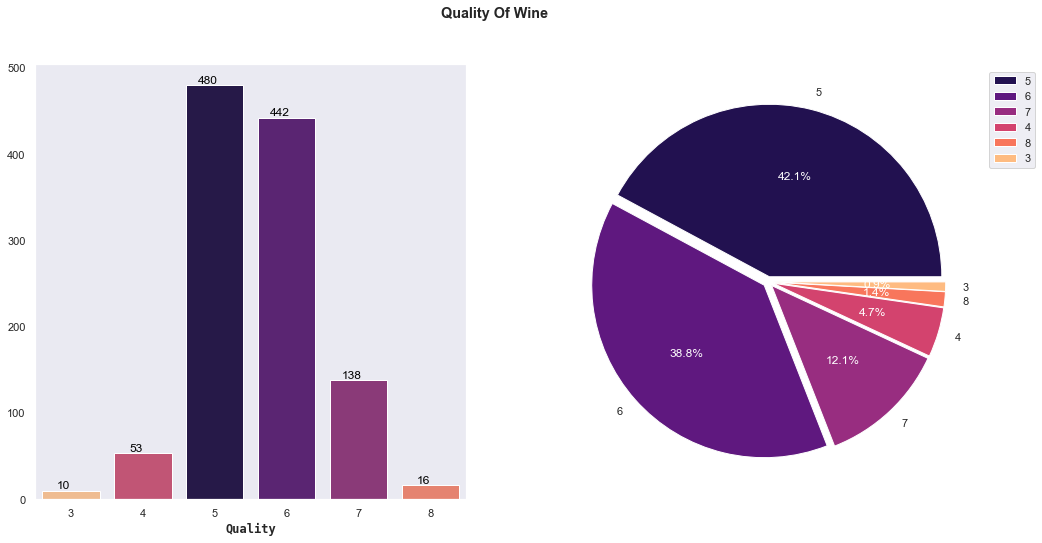

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(17,8))
x=df['quality'].value_counts().index
y=df['quality'].value_counts().values.tolist()
data = df.groupby("quality").size()
sns.set(style="dark", color_codes=True)
pal = sns.color_palette("magma", len(data))
rank = data.argsort().argsort() 
sns.barplot(x=x,y=y,palette=np.array(pal[::-1])[rank],ax = ax[0])
for p in ax[0].patches:
        ax[0].annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()),
                    ha='center', va='bottom',
                    color= 'black')
ax[0].set_xlabel('Quality', weight='semibold', fontname = 'monospace')
_, _, autotexts= ax[1].pie(y, labels = x, colors = pal, autopct='%1.1f%%',
        explode=[0.03 for i in df['quality'].value_counts().index])
for autotext in autotexts:
    autotext.set_color('white')
plt.legend(bbox_to_anchor=(1, 1))
plt.suptitle ('Quality Of Wine',weight = 'bold')
plt.show()

In [71]:
cat =['fixed acidity','volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide','density','pH','sulphates','alcohol']
print('No. of categorical columns are:',len(cat))

No. of categorical columns are: 11


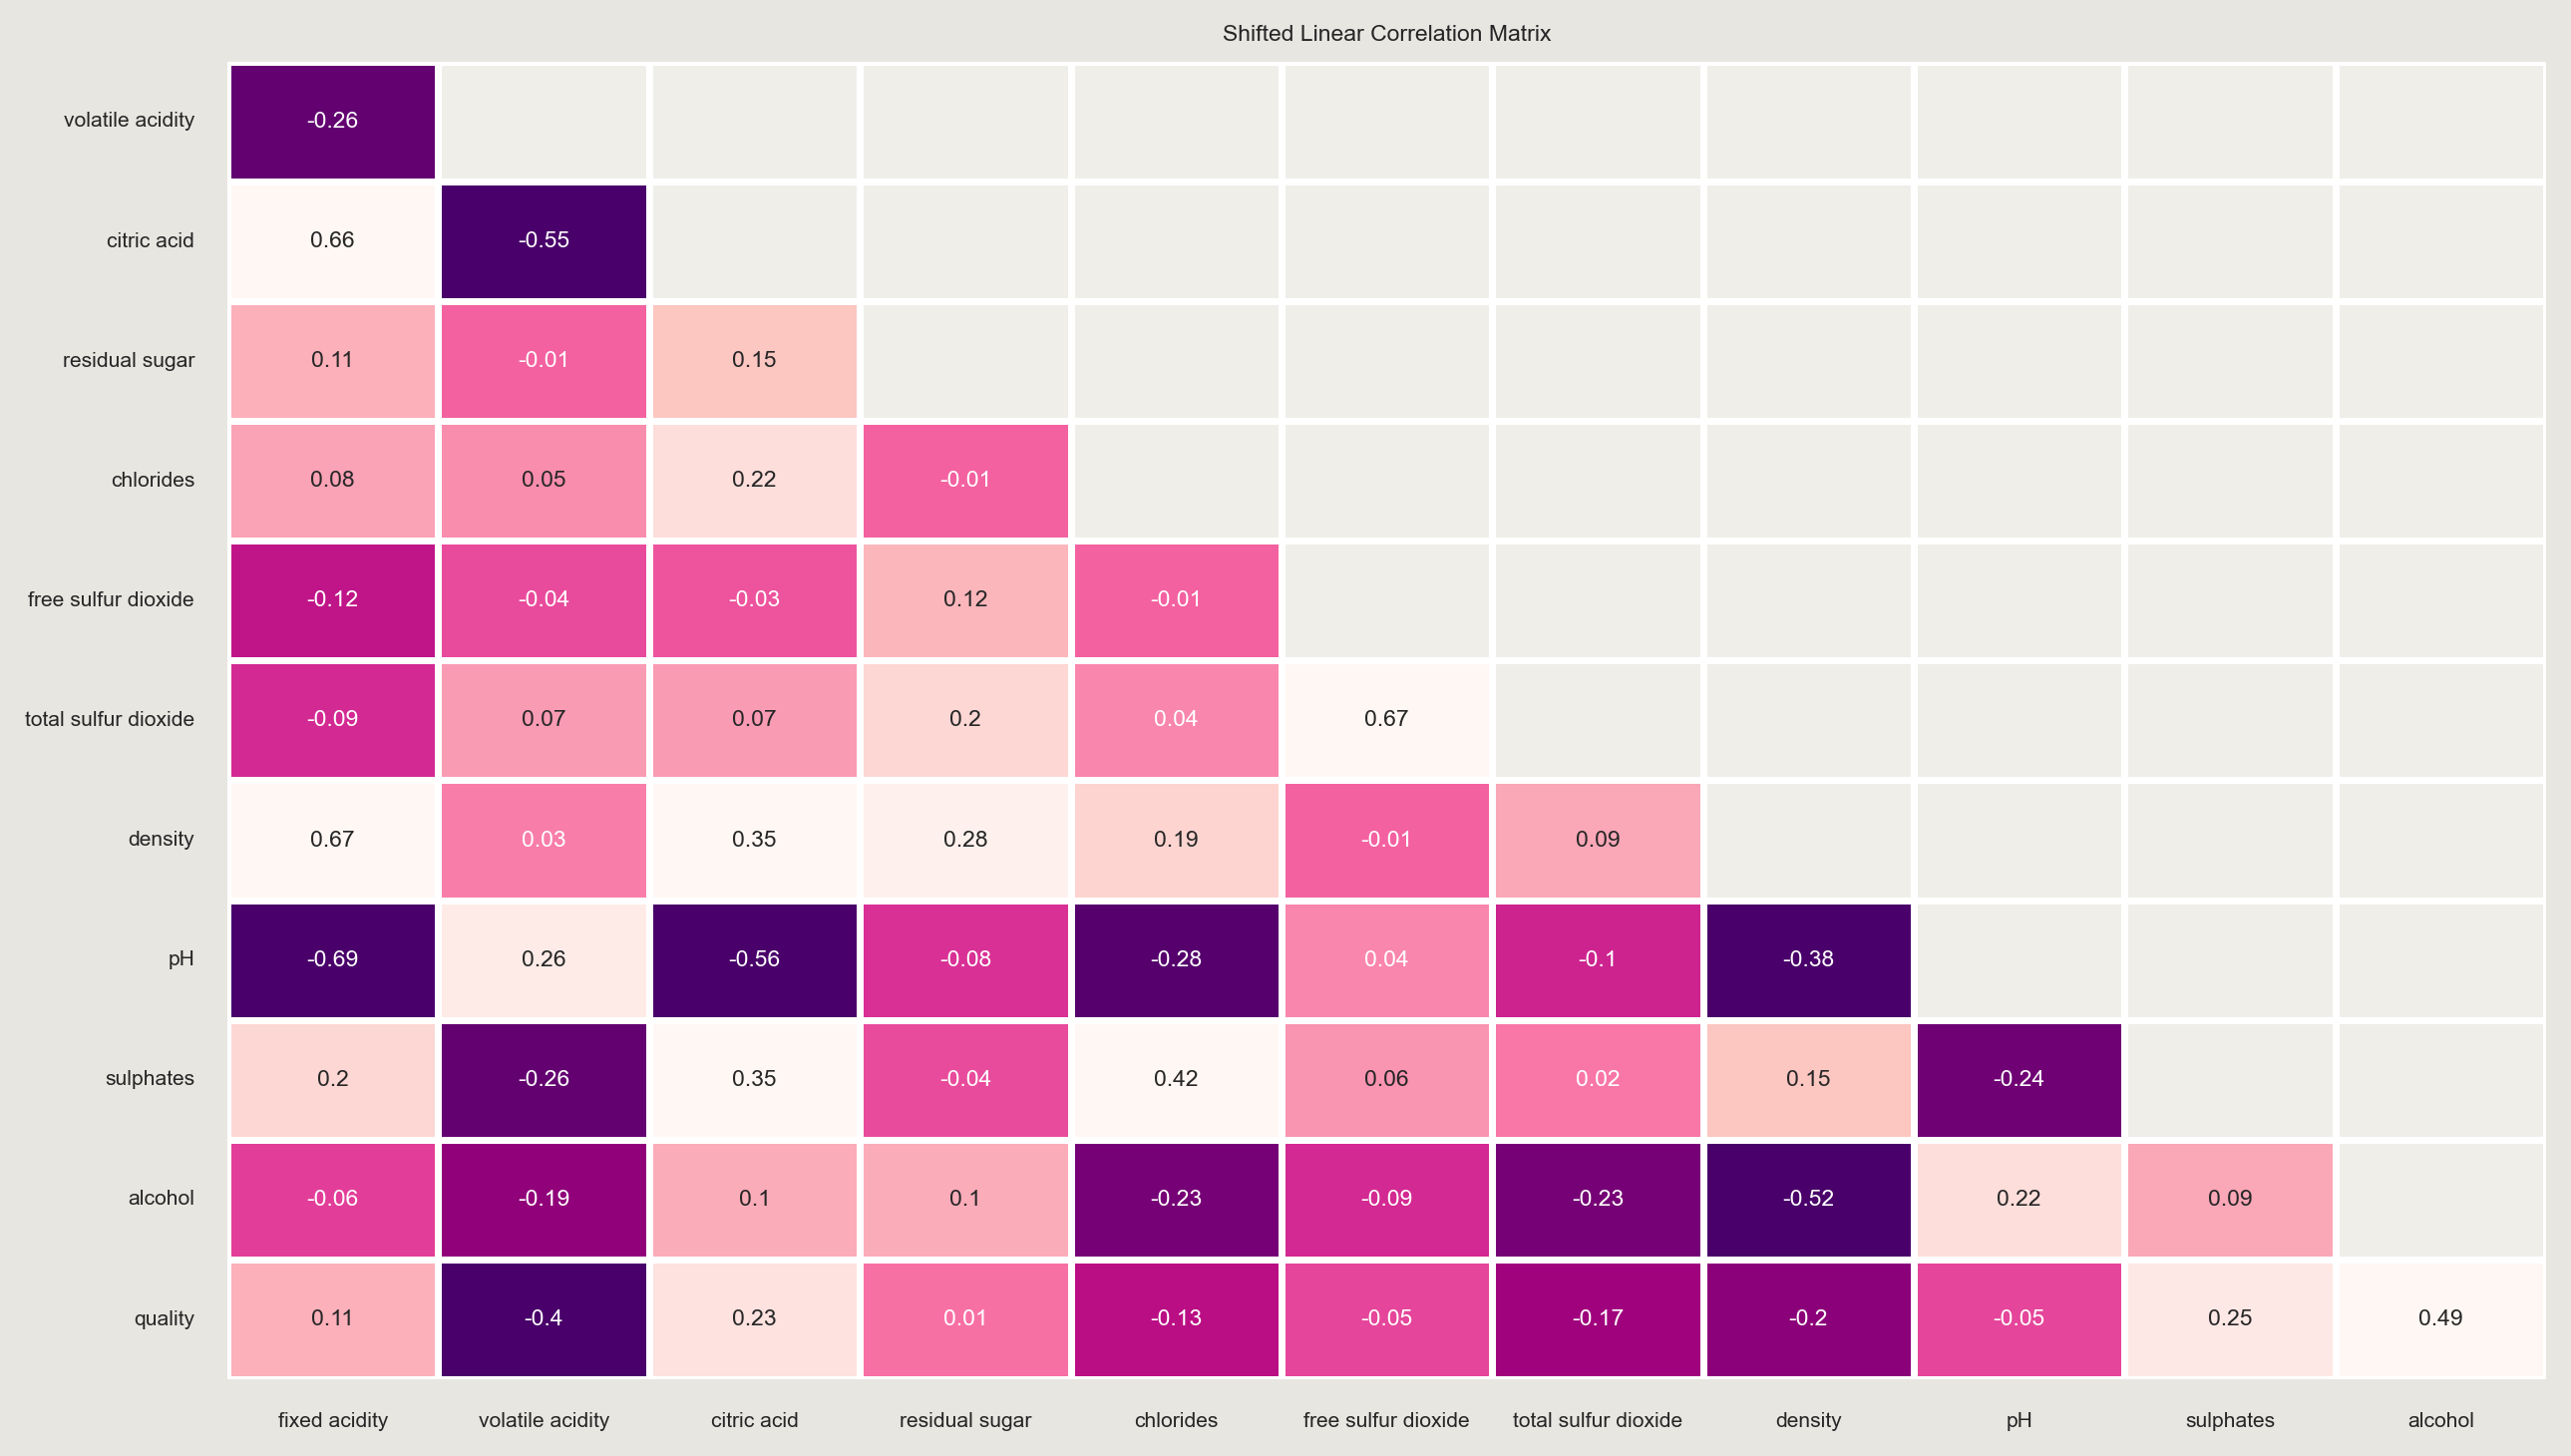

In [72]:
def corrMat(df,id=False):
    
    corr_mat = df.corr().round(2)
    f, ax = plt.subplots(figsize=(12,7))
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    mask = mask[1:,:-1]
    corr = corr_mat.iloc[1:,:-1].copy()
    sns.heatmap(corr,mask=mask,vmin=-0.3,vmax=0.3,center=0, 
                cmap='RdPu_r',square=False,lw=2,annot=True,cbar=False)

    ax.set_title('Shifted Linear Correlation Matrix')
    
corrMat(df)

In [1]:
#for index,col in enumerate(cat):
    
    #sns.barplot(x=df['quality'], y=df[col], data=df ,palette='magma')
    
    #plt.tight_layout()
    #plt.show()

In [84]:
#features = ['residual sugar', 'total sulfur dioxide', 'sulphates',
                   'alcohol', 'volatile acidity', 'quality','citric acid','chlorides','free sulfur dioxide']
#df_features = df[features]

In [137]:
df_temp = df.copy(deep=True)
X = df.drop('quality', axis=1)
y = df['quality']

In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

X=StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
scaler = StandardScaler()

In [139]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC()
svc.fit(X_train, y_train)
pred_svc_y = svc.predict(X_test)

In [140]:
svc.score(X_train,y_train)

0.6938519447929736

In [141]:
svc.score(X_test,y_test)

0.5321637426900585

In [132]:
#finding best params
param = {
    'C': [0.1,0.8,0.9,1,1.1,1.2,1.3,1.4],
    'kernel':['linear', 'rbf'],
    'gamma' :[0.1,0.8,0.9,1,1.1,1.2,1.3,1.4]
}
grid_svc = GridSearchCV(svc, param_grid=param, scoring='accuracy', cv=6)

grid_svc.fit(X_train, y_train)

GridSearchCV(cv=6, estimator=SVC(),
             param_grid={'C': [0.1, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4],
                         'gamma': [0.1, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [133]:
grid_svc.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [134]:
svc2 = SVC(C = 1, gamma =  0.1, kernel= 'rbf')
svc2.fit(X_train, y_train)
pred_svc2_y = svc2.predict(X_test)

In [135]:
svc2.score(X_train,y_train)

0.6925972396486826

In [136]:
svc2.score(X_test,y_test)

0.5233918128654971

## Obviously not the best score the point was trying the algorithm and experimenting the coding process